<a href="https://colab.research.google.com/github/peperjet/creditcard/blob/main/train_260325.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [63]:
import pandas as pd

train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')

In [64]:

# 위에서 5줄 보여줌
train.head()



,index,gender,car,reality,child_num,income_total,income_type,edu_type,family_type,house_type,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,work_phone,phone,email,occyp_type,family_size,begin_month,credit
0,0,F,N,N,0,202500.0,Commercial associate,Higher education,Married,Municipal apartment,-13899,-4709,1,0,0,0,NaN,2.0,-6.0,1.0
1,1,F,N,Y,1,247500.0,Commercial associate,Secondary / secondary special,Civil marriage,House / apartment,-11380,-1540,1,0,0,1,Laborers,3.0,-5.0,1.0
2,2,M,Y,Y,0,450000.0,Working,Higher education,Married,House / apartment,-19087,-4434,1,0,1,0,Managers,2.0,-22.0,2.0
3,3,F,N,Y,0,202500.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-15088,-2092,1,0,1,0,Sales staff,2.0,-37.0,0.0
4,4,F,Y,Y,0,157500.0,State servant,Higher education,Married,House / apartment,-15037,-2105,1,0,0,0,Managers,2.0,-26.0,2.0


나이 컬럼 만들기

In [65]:
train['age'] = (-train['DAYS_BIRTH'] // 365).astype(int)
test['age'] = (-test['DAYS_BIRTH'] // 365).astype(int)

train = train.drop('DAYS_BIRTH', axis=1)
test = test.drop('DAYS_BIRTH', axis=1)

train[['age']].head()

,age
0,38
1,31
2,52
3,41
4,41


타겟 확인 : credit 분포


In [66]:
train['credit'].value_counts()

,count
credit,
2.0,16968
1.0,6267
0.0,3222


결측치 확인

In [67]:
train.isnull().sum()

,0
index,0
gender,0
car,0
reality,0
child_num,0
income_total,0
income_type,0
edu_type,0
family_type,0
house_type,0


occyp_type 처리

In [68]:
train['occyp_type'] = train['occyp_type'].fillna('Unknown')
test['occyp_type'] = test['occyp_type'].fillna('Unknown')

train.isnull().sum()

,0
index,0
gender,0
car,0
reality,0
child_num,0
income_total,0
income_type,0
edu_type,0
family_type,0
house_type,0


이상치 확인 (Boxplot)

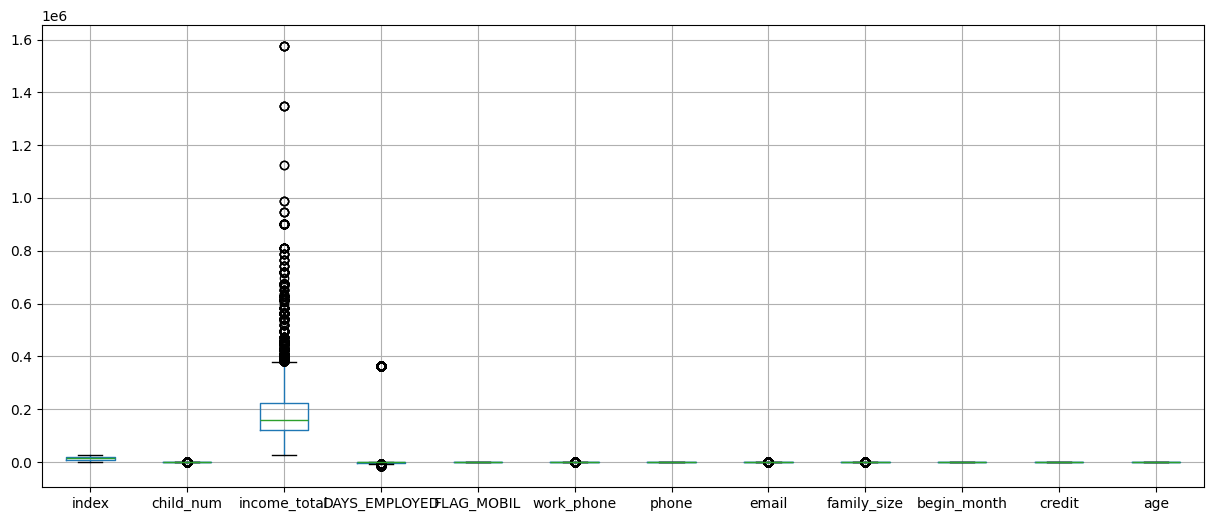

In [69]:
import matplotlib.pyplot as plt

train.boxplot(figsize=(15,6))
plt.show()

*   income_total(소득)
      -  점들이 위로 엄청 튀어있음 : 이상치 확실
*   DAYS_EMPLOYED
      - 값이 엄청 크게 튀는 점.
      - 음수/이상값 섞여 있음


너무 큰 값 때문에 모델이 왜곡됨.
로그 변환.

큰 값 눌러서 분포 안정화

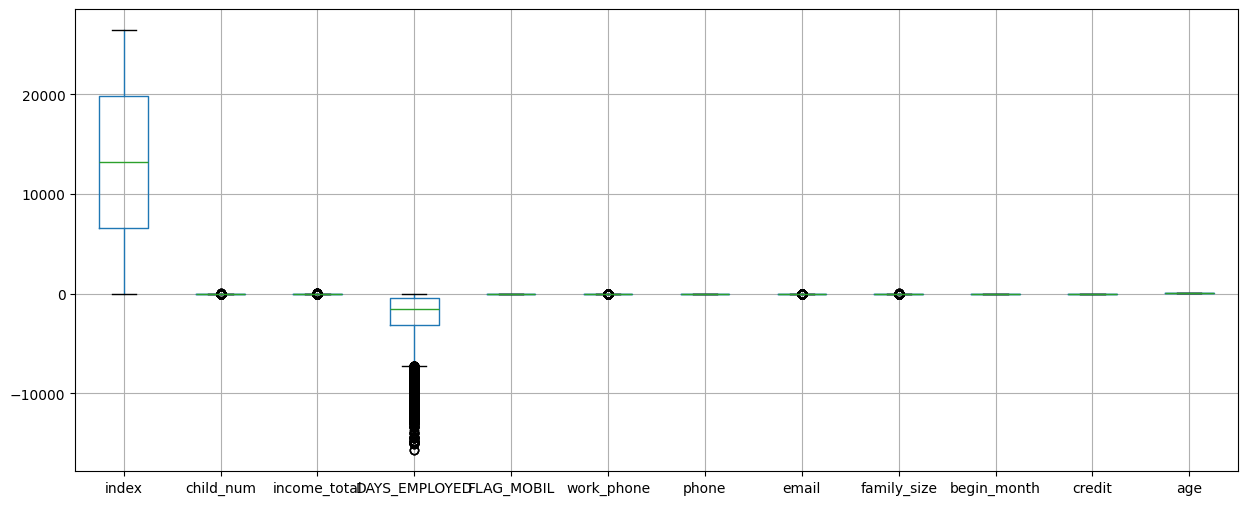

In [70]:
import numpy as np

train['income_total'] = np.log1p(train['income_total'])
test['income_total'] = np.log1p(test['income_total'])

train['DAYS_EMPLOYED'] = train['DAYS_EMPLOYED'].replace(365243, 0)
test['DAYS_EMPLOYED'] = test['DAYS_EMPLOYED'].replace(365243, 0)

train.boxplot(figsize=(15,6))
plt.show()

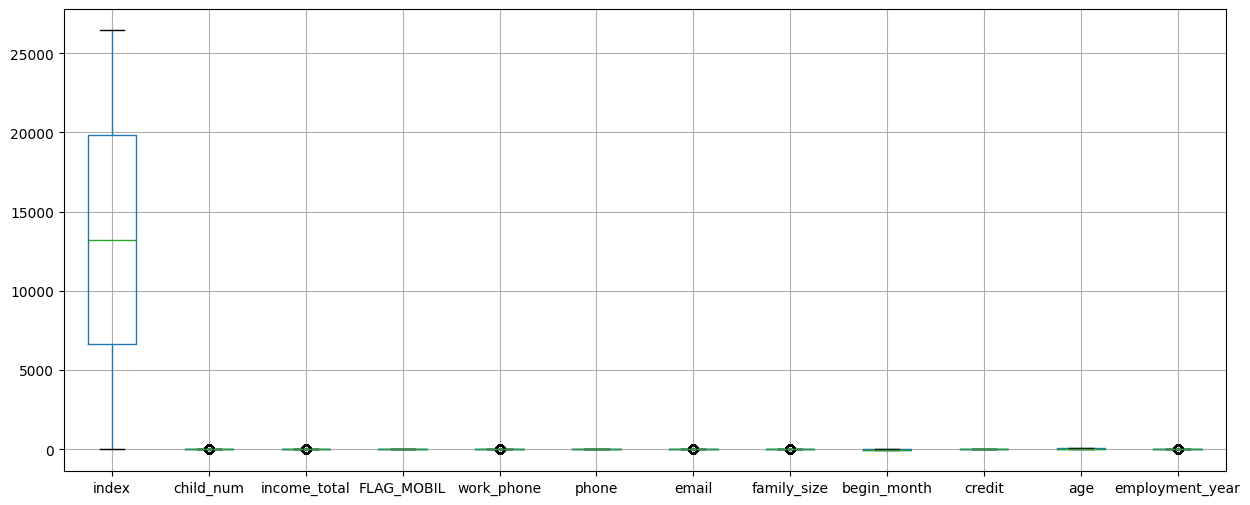

In [71]:
train['employment_year'] = (-train['DAYS_EMPLOYED'] // 365).astype(int)
test['employment_year'] = (-test['DAYS_EMPLOYED'] // 365).astype(int)

train = train.drop('DAYS_EMPLOYED', axis=1)
test = test.drop('DAYS_EMPLOYED', axis=1)

train.boxplot(figsize=(15,6))
plt.show()

In [74]:
train = train.drop('index', axis=1, errors='ignore')
test = test.drop('index', axis=1, errors='ignore')

In [75]:
train.columns

Index(['gender', 'car', 'reality', 'child_num', 'income_total', 'income_type',
       'edu_type', 'family_type', 'house_type', 'FLAG_MOBIL', 'work_phone',
       'phone', 'email', 'occyp_type', 'family_size', 'begin_month', 'credit',
       'age', 'employment_year'],
      dtype='object')

In [77]:
train.skew(numeric_only=True)

,0
child_num,2.852376
income_total,0.092333
FLAG_MOBIL,0.000000
work_phone,1.318953
phone,0.903042
email,2.838422
family_size,1.431759
begin_month,-0.290050
credit,-1.124384
age,0.187057


로그 변환 해야하는 것
연속형  (숫자 크기 의미 있는 것)

child_num
family_size
employment_year


In [78]:
import numpy as np

train['child_num'] = np.log1p(train['child_num'])
test['child_num'] = np.log1p(test['child_num'])

train['family_size'] = np.log1p(train['family_size'])
test['family_size'] = np.log1p(test['family_size'])

train['employment_year'] = np.log1p(train['employment_year'])
test['employment_year'] = np.log1p(test['employment_year'])

건드리지 말 것

👉 0/1 같은 이진값

work_phone
email
FLAG_MOBIL

In [79]:
train.skew(numeric_only=True)

,0
child_num,1.199640
income_total,0.092333
FLAG_MOBIL,0.000000
work_phone,1.318953
phone,0.903042
email,2.838422
family_size,0.138717
begin_month,-0.290050
credit,-1.124384
age,0.187057


범주형 인코딩 (Feature Extraction)

In [80]:
train = pd.get_dummies(train)
test = pd.get_dummies(test)

In [81]:
# train/test 컬럼 맞추기
train, test = train.align(test, join='left', axis=1, fill_value=0)

왜도 처리 끝, 문자 데이터 숫자로 바꾸는 단계

In [82]:
# 범주형 -> 숫자 변환 (인코딩)
train = pd.get_dummies(train)
test = pd.get_dummies(test)

In [83]:
#train / test 컬럼 맞추기
train, test = train.align(test, join='left', axis=1, fill_value=0)

In [84]:
train.shape, test.shape

((26457, 57), (10000, 57))

모델 학습 들어가기

In [85]:
from sklearn.ensemble import RandomForestClassifier

X = train.drop('credit', axis=1)
y = train['credit']

model = RandomForestClassifier()
model.fit(X, y)

RandomForestClassifier()

In [86]:
# 학습 실행
model.fit(X, y)

RandomForestClassifier()

In [95]:
pred = model.predict(test)

In [98]:
pred[:10]

array([2., 0., 2., 2., 2., 2., 0., 2., 2., 2.])

In [99]:
# 개수 확인
len(pred)

10000

제출파일 만들기

In [102]:
submission = pd.read_csv('/content/sample_submission.csv')
submission['credit'] = pred
submission.head()

,index,0,1,2,credit
0,26457,0,0,0,2.0
1,26458,0,0,0,0.0
2,26459,0,0,0,2.0
3,26460,0,0,0,2.0
4,26461,0,0,0,2.0


In [104]:
# 저장
submission.to_csv('submission.csv', index=False)

In [105]:
import os
os.listdir()

['.config',
 'sample_submission.csv',
 'submission.csv',
 'test.csv',
 'train.csv',
 '.ipynb_checkpoints',
 'sample_data']

In [106]:
# 파일 다운로드
from google.colab import files
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>